# Guía Práctica: "Primeros pasos en el ecosistema Python para Datos"

Curso de Fundamentos de Ciencia de Datos

**Objetivo de la clase**: Mostrar el flujo de trabajo fundamental en Data Science usando las 3 librerías core, preparando el terreno para EDA.

## 0. Setup y Conceptos Iniciales
¿Por qué estas 3 herramientas?

- [**NumPy**](https://numpy.org): Le da a Python el poder de las operaciones numéricas rápidas (arrays).

- [**Pandas**](https://pandas.pydata.org/): Trae la tabla (DataFrame) a Python. Ideal para manipular y limpiar.

- [**SciPy**](https://scipy.org/): La caja de herramientas para estadística y métodos científicos.



In [1]:
# Importaciones estándar (siempre al inicio)
import numpy as np          # np: abreviatura universal
import pandas as pd         # pd: abreviatura universal
from scipy import stats     # stats: módulo estadístico clave

# Configuración estética para pandas (opcional pero útil)
pd.set_option('display.precision', 2)

ModuleNotFoundError: No module named 'scipy'

## 1. NumPy: La Base Numérica
Todo en datos se reduce a arrays (vectores y matrices).

**NumPy** hace que las operaciones sean muy rápidas.

La clave: *ndarray* (_N-dimensional array_).

- Permite almacenar datos homogéneos y multidimensionales
- Garantiza que todos los elementos tengan el mismo tipo de dato y tamaño de memoria.
- Se piensa en bloques, no en elementos


In [ ]:
print("- Array o ndarray: La estructura de datos esencial. Es una grilla de valores del mismo tipo.\n")

# 1. Crear arrays
lista_python = [1, 2, 3, 4, 5]
arr_basico = np.array(lista_python)
print(f"Desde lista Python: {arr_basico}")
print(f"Tipo de dato: {arr_basico.dtype}") # <-- Punto clave: un solo tipo

arr_ceros = np.zeros(5)
print(f"\nArray de ceros: {arr_ceros}")
arr_rango = np.arange(0, 10, 2)  # inicio, fin, paso
print(f"Array con arange: {arr_rango}")

- Array o ndarray: La estructura de datos esencial. Es una grilla de valores del mismo tipo.

Desde lista Python: [1 2 3 4 5]
Tipo de dato: int64

Array de ceros: [0. 0. 0. 0. 0.]
Array con arange: [0 2 4 6 8]


Pregunta: ¿Diferencias entre range() y np.arange()?

In [ ]:
# 2. Diferencias clave con listas: Vectorización
print("\n\n--- Poder de Vectorización ---")
datos_ventas = np.array([100, 150, 200, 120])
print(f"Datos de venta: {datos_ventas}")

con_aumento = datos_ventas * 1.10 # Aplica a cada elemento, sin bucles
print(f"Ventas + 10%   : {con_aumento}")

# Filtrar con máscaras booleanas
mask = datos_ventas > 130
ventas_altas = datos_ventas[mask]
print(f"Ventas > 130   : {ventas_altas}")

# Resumen estadístico rápido
print(f"Promedio de ventas: {datos_ventas.mean()}")
print(f"Desviación estándar: {datos_ventas.std():.2f}")



--- Poder de Vectorización ---
Datos de venta: [100 150 200 120]
Ventas + 10%   : [110. 165. 220. 132.]
Ventas > 130   : [150 200]
Promedio de ventas: 142.5
Desviación estándar: 37.67


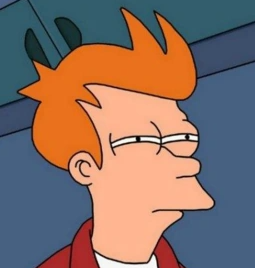

**Pregunta**: ¿Se podría lograr lo mismo utilizando solo listas?

## 2. Pandas: La Herramienta de Trabajo Diario

"*Si NumPy es el ladrillo, Pandas es la casa*".

- El objeto **DataFrame** es la tabla por excelencia.
- Vamos a realizar gran parte del análisis exploratorio (EDA) a través de Pandas.
- Cada columna de un DataFrame de Pandas es un objeto **Series**
  - Un objeto Series es un 1D-array capaz de almacenar cualquier tipo de dato (enteros, cadenas de texto, números de coma flotante, etc.).





### 2a. DataFrames comandos básicos

In [ ]:
# --- Cargar datos ---
# Usamos un dataset clásico "tips"
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'
df = pd.read_csv(url)

# --- Primer vistazo: funciones básicas ---
print("1. PRIMER VISTAZO AL DATAFRAME df")
print("--- head() ---")
print(df.head(3))  # 3 primeras filas

print("\n--- info() ---")
df.info()  # Tipos de datos y nulos

print("\n--- describe() ---")
print(df.describe(include="all"))  # Estadísticos de columnas numéricas

print("\n--- shape ---")
print(f"Filas y columnas: {df.shape}")

print("\n--- columns ---")
print(f"Nombre de columnas: {df.columns.tolist()}")

1. PRIMER VISTAZO AL DATAFRAME df
--- head() ---
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3

--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB

--- describe() ---
        total_bill     tip   sex smoker  day    time    size
count       244.00  244.00   244    244  244     244  244.00
unique         NaN     NaN     2      2  

### 2b. Selección y Filtros

In [ ]:
# --- Seleccionar y Filtrar ---
print("\n2. SELECCIÓN Y FILTROS")

# Seleccionar 1 columna (devuelve Serie)
propinas = df['tip']
print(f"Tipo de 'propinas': {type(propinas)} - Es una Serie de pandas")

# Seleccionar varias columnas (devuelve DataFrame)
sub_df = df[['total_bill', 'tip', 'day']]
print("\nSub-DataFrame con 3 columnas:")
print(sub_df.head(2))

# Filtros booleanos (igual que NumPy, pero más expresivo)
domingos = df[df['day'] == 'Sun']
print(f"\nNúmero de cuentas del domingo: {len(domingos)}")

# Crear columna nueva
df['propina_pct'] = df['tip'] / df['total_bill'] * 100
print("\nNueva columna 'propina_pct':")
print(df[['total_bill', 'tip', 'propina_pct']].head())

# Funciones de agregación (Groupby)
print("\n--- groupby (la función de agregación) ---")
resumen_dia = df.groupby('day')['total_bill'].mean().sort_values()
print("Cuenta promedio por día:")
print(resumen_dia)


2. SELECCIÓN Y FILTROS
Tipo de 'propinas': <class 'pandas.core.series.Series'> - Es una Serie de pandas

Sub-DataFrame con 3 columnas:
   total_bill   tip  day
0       16.99  1.01  Sun
1       10.34  1.66  Sun

Número de cuentas del domingo: 76

Nueva columna 'propina_pct':
   total_bill   tip  propina_pct
0       16.99  1.01         5.94
1       10.34  1.66        16.05
2       21.01  3.50        16.66
3       23.68  3.31        13.98
4       24.59  3.61        14.68

--- groupby (El Resumidor) ---
Cuenta promedio por día:
day
Fri     17.15
Thur    17.68
Sat     20.44
Sun     21.41
Name: total_bill, dtype: float64


### 2c. Pandas super rápido

- ✅ Tenemos funciones básica (read_csv, info, describe),
- ✅ usamos filtros y
- ✅ podemos agregar datos

Ya tenemos una gran base del EDA 🔥🔥🔥

## 3. SciPy: El Laboratorio Estadístico

Pandas tiene mucha estadística, pero cuando necesitamos pruebas de hipótesis, distribuciones o tests más complejos, vamos a utilizar **SciPy** que viene a complementar a Pandas.

In [ ]:
# Recuperamos los datos de propinas
propinas_almuerzo = df[df['time'] == 'Lunch']['tip']
propinas_cena = df[df['time'] == 'Dinner']['tip']

# 1. Describir con SciPy
print("Estadísticas con SciPy:")
print(f"  Curtosis del total de cuentas: {stats.kurtosis(df['total_bill']):.2f}")


# 2. Distribuciones Teóricas
# Simular: Si las propinas se distribuyeran normalmente...
media, std = propinas_cena.mean(), propinas_cena.std()
print(f"\n Media: {media:.3f} / desviación estandar: {std:.3f}")
valores_teoricos = np.linspace(media - 3*std, media + 3*std, 100) # ¿Recuerdan el range y arange?
distribucion_normal = stats.norm.pdf(valores_teoricos, media, std)
print(f"\n Altura de la curva normal en el punto medio: {distribucion_normal[50]:.2f}")

# 3. Test estadístico (el más clásico para 2 grupos)
# ¿Son diferentes las propinas en almuerzo y cena? (Test t para 2 muestras independientes)
stat, p_valor = stats.ttest_ind(propinas_almuerzo, propinas_cena)
print("\n--- Test de Hipótesis (t-test) ---")
print(f"  ¿Es igual la propina media en Lunch vs Dinner?")
print(f"  Estadístico t: {stat:.3f}")
print(f"  Valor p: {p_valor:.4f}")

alpha = 0.05
if p_valor < alpha:
    print(f"  Conclusión: Como p < {alpha}, RECHAZAMOS igualdad. Las medias son significativamente diferentes.")
else:
    print(f"  Conclusión: Como p >= {alpha}, NO rechazamos igualdad. Diferencia no es significativa.\n")

Estadísticas con SciPy:
  Curtosis del total de cuentas: 1.17

 Media: 3.103 / desviación estandar: 1.436

 Altura de la curva normal en el punto medio: 0.28

--- Test de Hipótesis (t-test) ---
  ¿Es igual la propina media en Lunch vs Dinner?
  Estadístico t: -1.906
  Valor p: 0.0578
  Conclusión: Como p >= 0.05, NO rechazamos igualdad. Diferencia no es significativa.



✅ Dimos un sobrevuelo por lo que podemos hacer con SciPy.

En conclusión, hoy hemos sentado las bases del análisis de datos moderno:

1. vimos cómo **NumPy** optimiza el procesamiento numérico a gran escala,
2. cómo **Pandas** nos permite estructurar y dar sentido a la realidad tabular,
3. y de qué manera **SciPy** aporta el sustento matemático y estadístico indispensable.

Con estas herramientas, estamos listos para el siguiente nivel. En nuestra próxima sesión, pondremos la teoría en práctica enfrentándonos a un dataset real desde cero; realizaremos un análisis exploratorio de datos (EDA) completo donde técnicas como `describe()`, el filtrado estratégico, las agrupaciones con `groupby` y la visualización esencial serán los pilares para transformar datos brutos en información valiosa.

## Test de velocidad: NumPy vs Listas Python


In [ ]:
import numpy as np
import timeit

# Creamos datos de prueba: 1 millón de elementos
N = 1000000
lista = list(range(N))
array = np.arange(N)

print(f"\nDatos de prueba: {N:,} elementos")
print("-" * 40)

# --- Operación 1: Multiplicar por 2 ---
print("\n🔹 Operación: multiplicar cada elemento por 2")

tiempo_lista = timeit.timeit(
    stmt="[x * 2 for x in lista]",
    globals={"lista": lista},
    number=10
) / 10

tiempo_numpy = timeit.timeit(
    stmt="array * 2",
    globals={"array": array},
    number=10
) / 10

print(f"  Lista (comprensión): {tiempo_lista*1000:.2f} ms")
print(f"  NumPy (vectorizado): {tiempo_numpy*1000:.2f} ms")
print(f"  ✅ NumPy es {tiempo_lista / tiempo_numpy:.0f}x más rápido")


Datos de prueba: 1,000,000 elementos
----------------------------------------

🔹 Operación: multiplicar cada elemento por 2
  Lista (comprensión): 32.86 ms
  NumPy (vectorizado): 0.37 ms
  ✅ NumPy es 90x más rápido


# Trabajo Práctico - Repaso de conceptos

Este trabajo no requiere entrega, es un ejercicio para fijar algunos conceptos vistos en la clase.

## Instrucciones generales

Pueden resolverlo en esta misma Notebook de Colab como prefiera.

En cada respuesta, incluyan una breve justificación (1-2 frases) de por qué eligieron esa librería o esa función.

No necesitan cargar datasets externos; creen sus propios arrays y DataFrames pequeños para probar.

### Parte A: Elegir la herramienta correcta (sin código)

Para cada situación, respondan: ¿NumPy, Pandas o SciPy? y justifiquen en una frase.

|#| Situación	| ¿Qué usarías?|
|-|-----------|--------------|
|A1|Tengo los precios de 5 productos en una lista y quiero aumentarlos un 15% sin hacer un bucle.|NumPy (Porque permite realizar operaciones matemáticas sobre listas o arreglos completos de forma vectorizada, sin usar bucles explícitos.)|
|A2|Tengo una tabla con columnas edad, ingreso, provincia y quiero calcular el ingreso promedio por provincia.|Pandas (Porque está pensado para trabajar con tablas de datos y permite agrupar por provincia y calcular promedios fácilmente.)|
|A3|Quiero saber si la diferencia de altura entre dos grupos de plantas (grupo A y grupo B) es estadísticamente significativa.|SciPy (Porque incluye herramientas estadísticas, como pruebas de hipótesis, para evaluar si una diferencia entre grupos es significativa.)|
|A4|Tengo dos columnas de una tabla y quiero crear una tercera que sea la división de ambas, fila por fila.|Pandas (Porque permite operar directamente con columnas de una tabla y crear nuevas columnas a partir de cálculos fila por fila.)|


### Parte B: "Traducir" de listas a NumPy
El siguiente código usa listas de Python. Reescríbanlo usando NumPy sin bucles explícitos (vectorizado). Luego respondan:

In [ ]:
# Versión original con listas
temperaturas_celsius = [15, 22, 18, 30, 12, 25, 19, 28]

# 1. Convertir a Fahrenheit: F = C * 9/5 + 32
fahrenheit = []
for temp in temperaturas_celsius:
    fahrenheit.append(temp * 9/5 + 32)
    
#usando numpy
fahrenheit_numpy = np.array(temperaturas_celsius) * 9/5 + 32

# 2. Quedarse solo con las temperaturas > 20°C
altas = []
for temp in temperaturas_celsius:
    if temp > 20:
        altas.append(temp)

#usando numpy
temperaturas_celsius = np.array(temperaturas_celsius)
altas_numpy = temperaturas_celsius[temperaturas_celsius > 20]

# 3. Calcular el promedio
promedio = sum(temperaturas_celsius) / len(temperaturas_celsius)

#usando numpy
promedio = np.mean(temperaturas_celsius)

|#|Pregunta|
|-|-|
|B1|Reescriban la conversión a Fahrenheit con NumPy (1 línea).|
|B2|Reescriban el filtro de temperaturas > 20°C con NumPy (1 línea).|
|B3|¿Qué función de NumPy usarían para el promedio en vez de sum/len?|
|B4|Conceptual: Si temperaturas_celsius tuviera 10 millones de valores, <br/> ¿por qué la versión NumPy sería más rápida? <br/> 👀 No respondan "porque está en C"; expliquen qué pasa con la memoria y los bucles.<br>Respuesta: NumPy sería más rápido porque almacena los datos en arreglos homogéneos y continuos en memoria, lo que permite operar sobre muchos valores a la vez. En cambio, una lista de Python contiene objetos separados y requiere recorrerlos con un bucle explícito, agregando más sobrecarga de memoria y de interpretación en cada iteración.

### Parte C: Un mini EDA guiado con Pandas

Creen un DataFrame pequeño con datos de 8 libros:

In [ ]:
import pandas as pd

datos = {
    'titulo': ['Libro A', 'Libro B', 'Libro C', 'Libro D',
               'Libro E', 'Libro F', 'Libro G', 'Libro H'],
    'genero': ['Ficción', 'Ensayo', 'Ficción', 'Ciencia',
               'Ensayo', 'Ficción', 'Ciencia', 'Ciencia'],
    'precio': [1300, 2200, 900, 1500, 1800, 1100, 2000, 1600],
    'paginas': [320, 180, 450, 500, 230, 150, 600, 380]
}

df = pd.DataFrame(datos)

print(f"C1|¿Cuántas filas y columnas tiene el DataFrame?")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

print(f"C2|Muestren las primeras 3 filas. ¿Qué ven que les sirve para entender la estructura?")
print(df.head(3))

# |||
print(f"C3|¿Qué tipos de datos hay en cada columna? ¿Hay alguna que les llame la atención?")
print(df.dtypes)

print(f"C4|Obtengan estadísticos descriptivos de las columnas numéricas. ¿Qué dato les parece más relevante y por qué?")
print(df.describe())

print(f"C5|¿Cuál es el precio promedio de los libros de Ficción?")
precio_promedio_ficcion = df[df['genero'] == 'Ficción']['precio'].mean()
print(f"Precio promedio de libros de Ficción: {precio_promedio_ficcion:.2f}")

print(f"C6|Creen una nueva columna llamada precio_por_pagina que sea precio / paginas. ¿Qué libro tiene el mayor valor?")
df['precio_por_pagina'] = df['precio'] / df['paginas']
libro_mas_caro = df.loc[df['precio_por_pagina'].idxmax()]
print(f"Libro con mayor precio por página: {libro_mas_caro['titulo']} con {libro_mas_caro['precio_por_pagina']:.2f} por página")

print(f"C7|Agrupen por genero y calculen el promedio de paginas para cada uno. ¿Qué género tiene los libros más extensos en promedio?")
paginas_promedio_por_genero = df.groupby('genero')['paginas'].mean()
print(f"Promedio de páginas por género: {paginas_promedio_por_genero}")

print(f"C8|Conceptual: <br/>- ¿Por qué usamos pandas para C5 y C7 en vez de NumPy? <br/>- ¿Qué tiene pandas que NumPy no ofrece para estas tareas?")
print(f"Respuesta: Usamos pandas para C5 y C7 porque estamos trabajando con datos organizados en forma de tabla, con columnas que tienen nombres y significado")
print(f"En C5 necesitamos filtrar por una categoría, genero, y luego calcular el promedio de otra columna, precio. En C7 necesitamos agrupar los datos por genero y calcular el promedio de paginas para cada grupo.")
print(f"Pandas ofrece herramientas específicas para este tipo de tareas, como filtros por columnas, groupby(), selección por etiquetas y operaciones sobre DataFrames. NumPy trabaja muy bien con arreglos numéricos, pero no tiene de forma tan directa una estructura tabular con nombres de columnas, categorías y agrupamientos.")

C1|¿Cuántas filas y columnas tiene el DataFrame?
Filas: 8, Columnas: 4
<br>
C2|Muestren las primeras 3 filas. ¿Qué ven que les sirve para entender la estructura?
    titulo   genero  precio  paginas
0  Libro A  Ficción    1300      320
1  Libro B   Ensayo    2200      180
2  Libro C  Ficción     900      450
C3|¿Qué tipos de datos hay en cada columna? ¿Hay alguna que les llame la atención?
titulo     object
genero     object
precio      int64
paginas     int64
dtype: object
C4|Obtengan estadísticos descriptivos de las columnas numéricas. ¿Qué dato les parece más relevante y por qué?
            precio     paginas
count     8.000000    8.000000
mean   1550.000000  351.250000
std     444.007722  160.395716
min     900.000000  150.000000
25%    1250.000000  217.500000
50%    1550.000000  350.000000
75%    1850.000000  462.500000
max    2200.000000  600.000000
C5|¿Cuál es el precio promedio de los libros de Ficción?
Precio promedio de libros de Ficción: 1100.00
C6|Creen una nueva columna l

Usando este DataFrame, respondan escribiendo el código y comentando qué significa el resultado:

|#|Pregunta|¿Qué función de pandas usarían?|
|-|-|-|
|C1|¿Cuántas filas y columnas tiene el DataFrame?||
|C2|Muestren las primeras 3 filas. ¿Qué ven que les sirve para entender la estructura?||
|C3|¿Qué tipos de datos hay en cada columna? ¿Hay alguna que les llame la atención?||
|C4|Obtengan estadísticos descriptivos de las columnas numéricas. ¿Qué dato les parece más relevante y por qué?||
|C5|¿Cuál es el precio promedio de los libros de Ficción?||
|C6|Creen una nueva columna llamada precio_por_pagina que sea precio / paginas. ¿Qué libro tiene el mayor valor?||
|C7|Agrupen por genero y calculen el promedio de paginas para cada uno. ¿Qué género tiene los libros más extensos en promedio?||
|C8|Conceptual: <br/>- ¿Por qué usamos pandas para C5 y C7 en vez de NumPy? <br/>- ¿Qué tiene pandas que NumPy no ofrece para estas tareas?||